Read CSV File

In [1]:
import pandas as pd

# Load the CSV using a relative path from the notebook
df = pd.read_csv('../data/vv_data_20250722.csv')

print(df.shape)
df.head()

(1044, 23)


,Unnamed: 0,uid,price,suv_prob,vert_prob,sedan_prob,coupe_prob,hatchback_prob,window_damage_prob,door_damage_prob,...,average_cond_prob,year,make,model_name,trim,mileage,title_status,transmission,engine_cylinders,displacement
0,0,7865789467,1800.0,0.475830,0.511719,0.736328,0.074585,0.422119,0.457275,0.240845,...,0.200439,2003,Honda,Accord EX,EX,NaN,NaN,Automatic,NaN,NaN
1,1,7865784701,2800.0,0.186523,0.113647,0.741211,0.034515,0.250977,0.120483,0.157104,...,0.128296,2003,Honda,Accord,NaN,NaN,NaN,NaN,NaN,NaN
2,2,7865780123,1999.0,0.412354,0.242432,0.717773,0.027008,0.605957,0.320801,0.520508,...,0.392090,2000,Accord,Lx,NaN,159000,NaN,Needs repair/replace (current one is going out),NaN,NaN
3,3,7865763347,6995.0,0.137573,0.114441,0.713379,0.083740,0.314941,0.418457,0.186279,...,0.188599,2010,Honda,Accord LX Sedan 4-DOORS,LX,105000,clean,Automatic,4,2.4
4,4,7865716774,22000.0,0.622070,0.347656,0.853516,0.156128,0.516113,0.452393,0.161377,...,0.570801,18,Accord,Sport,NaN,81100,clean,NaN,NaN,NaN



Calculate Average Price and Listing Count for Each Make-Model

In [3]:
# Group by make and model_name, compute average price and listing count
summary = (
    df.groupby(['make', 'model_name'])
      .agg(avg_price=('price', 'mean'),
           listing_count=('uid', 'count'))
      .reset_index()
      .sort_values(by=['make', 'model_name'])
)

# Display results
summary.head(20)
summary.to_csv('../data/avg_price_by_make_model.csv', index=False)


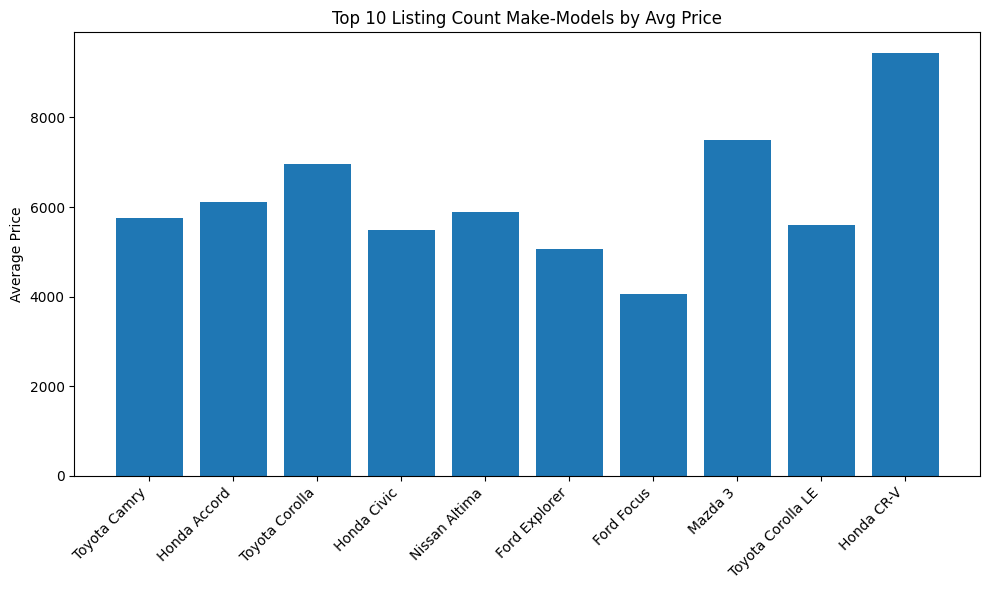

In [5]:
import matplotlib.pyplot as plt

# Combine make and model_name into a single label for plotting
summary['make_model'] = summary['make'] + ' ' + summary['model_name']

# Sort by listing count, take top 10
top10 = summary.sort_values('listing_count', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(top10['make_model'], top10['avg_price'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Price')
plt.title('Top 10 Listing Count Make-Models by Avg Price')
plt.tight_layout()
plt.show()


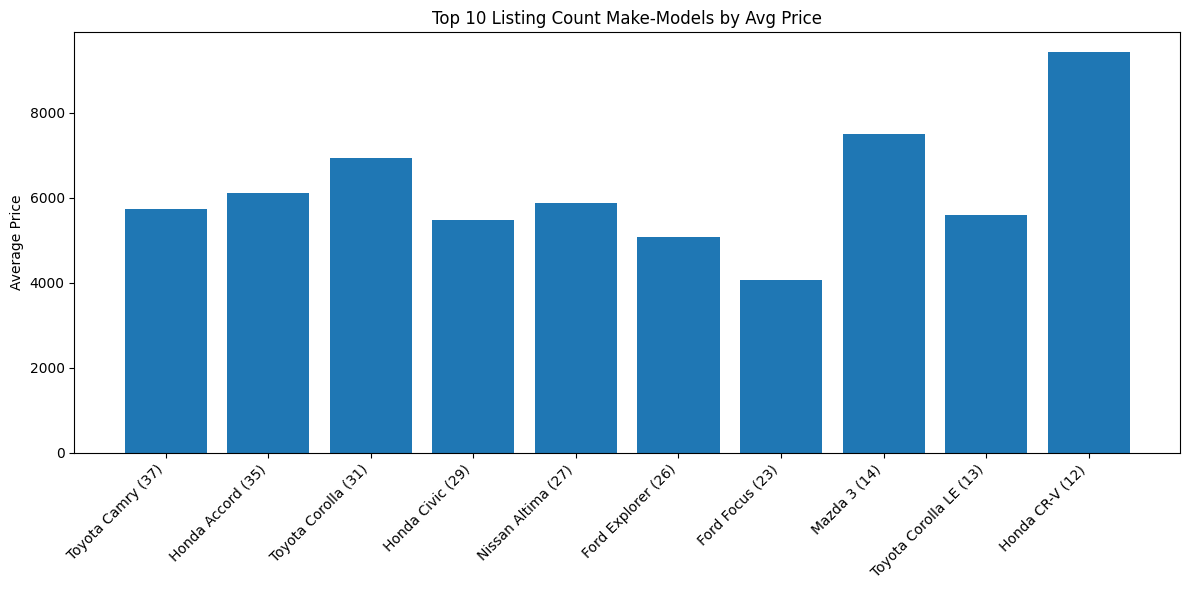

In [6]:
# Add listing count to label
top10['label'] = top10['make_model'] + ' (' + top10['listing_count'].astype(str) + ')'

plt.figure(figsize=(12, 6))
bars = plt.bar(top10['label'], top10['avg_price'])

plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Price')
plt.title('Top 10 Listing Count Make-Models by Avg Price')
plt.tight_layout()
plt.show()


See Distribution of Car Condition Against Price for Top 10 Listing Make-Model

In [7]:
top10_make_models = (
    summary.sort_values('listing_count', ascending=False)
    .head(10)[['make', 'model_name']]
)

# Merge to keep only rows from top 10 make-models
top10_df = df.merge(top10_make_models, on=['make', 'model_name'])


In [8]:
def condition_label(prob):
    if prob >= 0.8:
        return 'Excellent'
    elif prob >= 0.5:
        return 'Good'
    elif prob >= 0.2:
        return 'Fair'
    else:
        return 'Poor'

top10_df['condition'] = top10_df['excellent_cond_prob'].apply(condition_label)


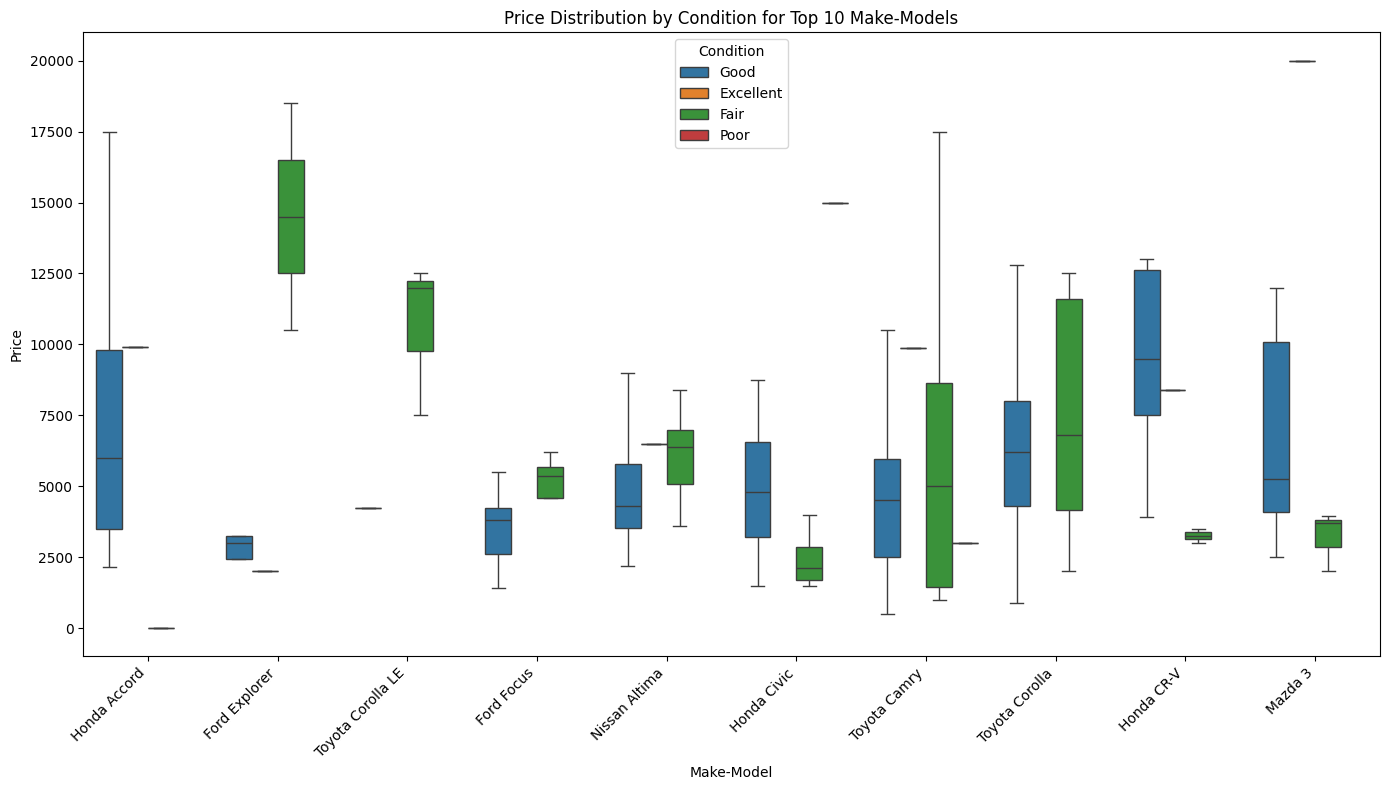

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Combine make and model for plot labels
top10_df['make_model'] = top10_df['make'] + ' ' + top10_df['model_name']

plt.figure(figsize=(14, 8))
sns.boxplot(
    data=top10_df,
    x='make_model',
    y='price',
    hue='condition',
    showfliers=False
)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Price')
plt.xlabel('Make-Model')
plt.title('Price Distribution by Condition for Top 10 Make-Models')
plt.legend(title='Condition')
plt.tight_layout()
plt.show()


For each of the excellence category, get mean, mode, median to see the distrubition of average price

In [28]:
import pandas as pd
from scipy.stats import mode

print(df['price'].dtype)
print(top10_df['price'].dtype)


# Group by make_model and condition, then aggregate
def robust_mode(x):
    print("MODE INPUT:", x.tolist())
    m = x.mode()
    if not m.empty:
        return m.iloc[0]
    return x.iloc[0] if len(x) == 1 else None

def robust_median(x):
    print("MEDIAN INPUT:", x.tolist())
    if len(x) == 1:
        return x.iloc[0]
    return x.median()

agg = (
    top10_df.groupby(['make_model', 'condition'])
      .agg(
          mean_price=('price', 'mean'),
          median_price=('price', lambda x: float(x.iloc[0]) if len(x) == 1 else float(x.median())),
          mode_price=('price', lambda x: float(x.iloc[0]) if len(x) == 1 else (float(x.mode().iloc[0]) if not x.mode().empty else None)),
          count=('price', 'count')
      )
      .reset_index()
      .sort_values(['make_model', 'condition'])
)


agg


# Display results
agg



float64
float64


,make_model,condition,mean_price,median_price,mode_price,count
0,Ford Explorer,Excellent,2000.000000,2000.0,2000.0,1
1,Ford Explorer,Fair,14500.000000,14500.0,10500.0,2
2,Ford Explorer,Good,4388.913043,3000.0,3250.0,23
3,Ford Focus,Fair,4925.000000,5350.0,2800.0,4
4,Ford Focus,Good,3875.736842,3799.0,3999.0,19
5,Honda Accord,Excellent,9900.000000,9900.0,9900.0,1
6,Honda Accord,Fair,1400.600000,1.0,1.0,5
7,Honda Accord,Good,6789.482759,6000.0,2200.0,29
8,Honda CR-V,Excellent,8400.000000,8400.0,8400.0,1
9,Honda CR-V,Fair,3250.000000,3250.0,3000.0,2


In [29]:
print(top10_df[(top10_df['make_model'] == 'Honda Accord') & (top10_df['condition'] == 'Fair')][['price']])


      price
15   6999.0
31      1.0
133     1.0
134     1.0
190     1.0


In [17]:
agg.to_csv('../data/top10_make_model_condition_stats.csv', index=False)

Apply the same categorization for all records

In [18]:
def condition_label(prob):
    if prob >= 0.8:
        return 'Excellent'
    elif prob >= 0.5:
        return 'Good'
    elif prob >= 0.2:
        return 'Fair'
    else:
        return 'Poor'

df['condition'] = df['excellent_cond_prob'].apply(condition_label)

In [19]:
agg_all = (
    df.groupby(['make', 'model_name', 'condition'])
      .agg(
          mean_price=('price', 'mean'),
          median_price=('price', 'median'),
          mode_price=('price', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
          count=('price', 'count')
      )
      .reset_index()
      .sort_values(['make', 'model_name', 'condition'])
)

In [20]:
agg_all.to_csv('../data/all_make_model_condition_stats.csv', index=False)

Find out the price fluctuation within a make-model

1) By condition: For each make-model, shows the condition category with the highest mean price

In [30]:
import pandas as pd

agg = pd.read_csv('../data/all_make_model_condition_stats.csv')

# For each make-model, find the row with the highest mean_price
idx = agg.groupby(['make', 'model_name'])['mean_price'].idxmax()
max_condition = agg.loc[idx].reset_index(drop=True)

# Show the results
max_condition[['make', 'model_name', 'condition', 'mean_price']]


,make,model_name,condition,mean_price
0,Accord,Lx,Good,1999.0
1,Accord,Sport,Good,20250.0
2,Acura,RL,Good,3800.0
3,Altima,SV,Good,6300.0
4,Altima,Sv,Fair,5999.0
...,...,...,...,...
345,not available,not available,Good,8769.8
346,"not mentioned explicitly, but similar to Honda...","similar to Civic, Elantra, Jetta, Vibe, Focus,...",Good,4800.0
347,si coupé premium,salvage title,Fair,8950.0
348,unknown,unknown,Fair,6000.0


In [32]:
# Count how many times each condition is the highest mean price
most_common = max_condition['condition'].value_counts()

print(most_common)


condition
Good         263
Fair          59
Excellent     27
Poor           1
Name: count, dtype: int64


Check distribution of conditions

count    1044.000000
mean        0.624505
std         0.128127
min         0.055298
25%         0.545776
50%         0.639404
75%         0.716919
max         0.889160
Name: excellent_cond_prob, dtype: float64


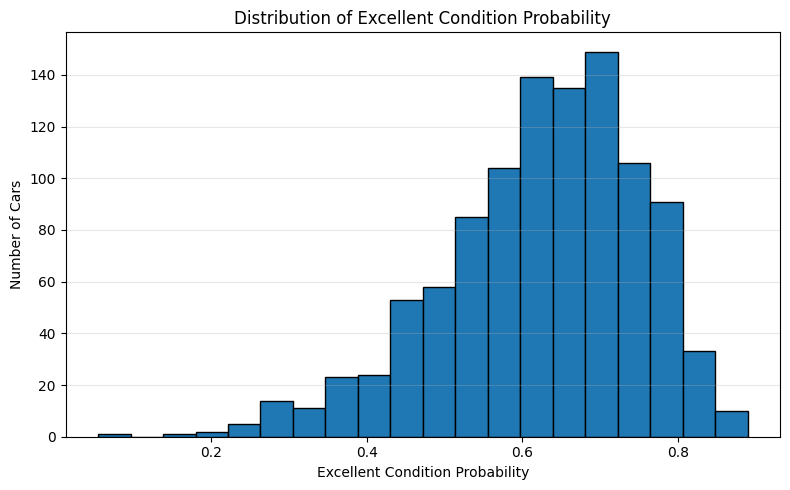

In [34]:
import pandas as pd

df = pd.read_csv('../data/vv_data_20250722.csv')  # Replace with your actual file name

print(df['excellent_cond_prob'].describe())

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df['excellent_cond_prob'], bins=20, edgecolor='k')
plt.title('Distribution of Excellent Condition Probability')
plt.xlabel('Excellent Condition Probability')
plt.ylabel('Number of Cars')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



See price distribution along with excellent condition

In [35]:
import pandas as pd
import numpy as np

# Bin the excellence probability into intervals
bins = np.linspace(0, 1, 11)  # 0.0, 0.1, ..., 1.0
df['excellence_bin'] = pd.cut(df['excellent_cond_prob'], bins=bins, include_lowest=True)

agg_bin = (
    df.groupby('excellence_bin')
      .agg(
          count=('price', 'count'),
          avg_price=('price', 'mean')
      )
      .reset_index()
)

/var/folders/jb/mvqq5sgs5b94qlsvcckcgwym0000gn/T/ipykernel_99935/1166612833.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('excellence_bin')


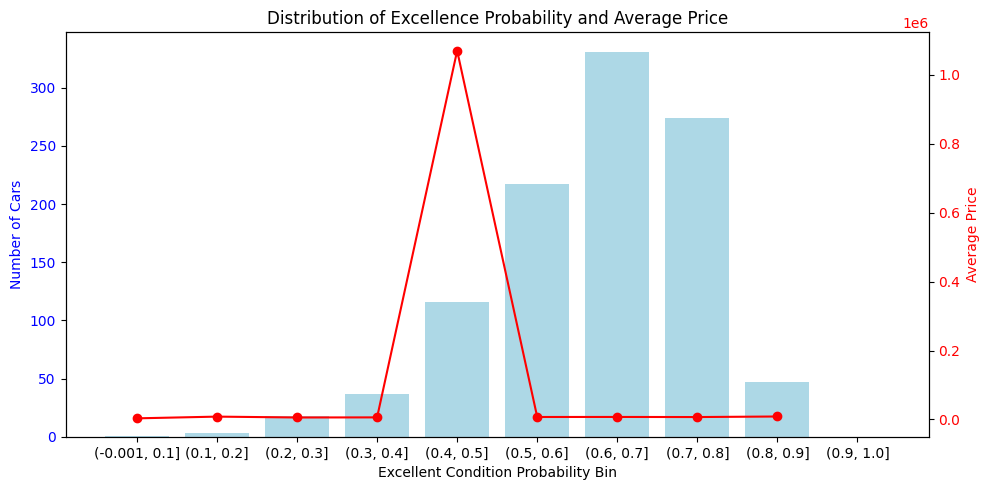

In [36]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot count as bar chart
ax1.bar(agg_bin['excellence_bin'].astype(str), agg_bin['count'], color='lightblue', label='Count')
ax1.set_xlabel('Excellent Condition Probability Bin')
ax1.set_ylabel('Number of Cars', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Plot average price as line chart on the same x-axis, different y-axis
ax2 = ax1.twinx()
ax2.plot(agg_bin['excellence_bin'].astype(str), agg_bin['avg_price'], color='red', marker='o', label='Average Price')
ax2.set_ylabel('Average Price', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Distribution of Excellence Probability and Average Price')
fig.tight_layout()
plt.show()


Price plot seems wrong, try to fix it

In [37]:
print(agg_bin)


  excellence_bin  count     avg_price
0  (-0.001, 0.1]      1  3.100000e+03
1     (0.1, 0.2]      3  8.100000e+03
2     (0.2, 0.3]     18  5.594167e+03
3     (0.3, 0.4]     37  5.881351e+03
4     (0.4, 0.5]    116  1.070187e+06
5     (0.5, 0.6]    217  7.015051e+03
6     (0.6, 0.7]    331  7.145405e+03
7     (0.7, 0.8]    274  6.854007e+03
8     (0.8, 0.9]     47  8.446404e+03
9     (0.9, 1.0]      0           NaN


In [38]:
for label in agg_bin['excellence_bin']:
    bin_df = df[df['excellence_bin'] == label]
    print(f'Bin: {label}, Count: {len(bin_df)}, Avg Price: {bin_df["price"].mean()}, Prices: {bin_df["price"].tolist()}')


Bin: (-0.001, 0.1], Count: 1, Avg Price: 3100.0, Prices: [3100.0]
Bin: (0.1, 0.2], Count: 3, Avg Price: 8100.0, Prices: [3000.0, 15000.0, 6300.0]
Bin: (0.2, 0.3], Count: 18, Avg Price: 5594.166666666667, Prices: [6995.0, 6900.0, 3600.0, 1200.0, 1000.0, 3500.0, 2400.0, 3250.0, 5800.0, 10000.0, 2500.0, 12000.0, 12000.0, 12000.0, 5200.0, 3200.0, 3950.0, 5200.0]
Bin: (0.3, 0.4], Count: 37, Avg Price: 5881.351351351352, Prices: [5250.0, 6900.0, 24995.0, 1495.0, 6500.0, 4800.0, 7000.0, 6000.0, 23000.0, 1495.0, 6000.0, 1900.0, 6800.0, 3500.0, 1495.0, 7000.0, 6500.0, 3000.0, 1500.0, 1495.0, 6500.0, 2000.0, 2500.0, 4000.0, 1495.0, 6500.0, 7500.0, 18500.0, 3200.0, 1495.0, 6500.0, 10900.0, 3200.0, 7700.0, 3500.0, 1495.0, 4000.0]
Bin: (0.4, 0.5], Count: 116, Avg Price: 1070187.2586206896, Prices: [2200.0, 2500.0, 4800.0, 11998.0, 6999.0, 1.0, 19500.0, 4500.0, 3900.0, 3600.0, 1.0, 1.0, 1.0, 1.0, 6998.0, 5900.0, 7800.0, 3800.0, 8400.0, 5999.0, 3300.0, 12000.0, 7500.0, 3500.0, 1950.0, 1200.0, 975.0, 

In [39]:
df_filtered = df[(df['price'] >= 500) & (df['price'] <= 100000)].copy()

agg_bin = (
    df_filtered.groupby('excellence_bin')
      .agg(
          count=('price', 'count'),
          avg_price=('price', 'mean')
      )
      .reset_index()
)


/var/folders/jb/mvqq5sgs5b94qlsvcckcgwym0000gn/T/ipykernel_99935/2940430671.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby('excellence_bin')


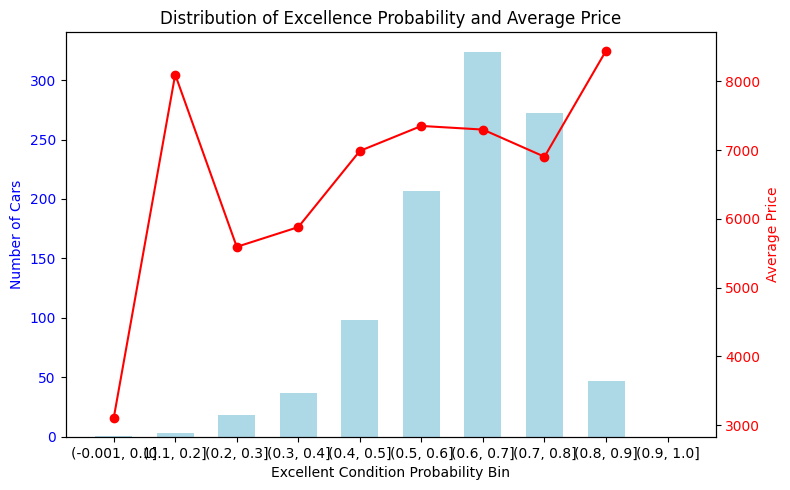

In [41]:
# Convert intervals to string labels
agg_bin['bin_label'] = agg_bin['excellence_bin'].astype(str)

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.bar(agg_bin['bin_label'], agg_bin['count'], color='lightblue', label='Count', width=0.6)
ax1.set_xlabel('Excellent Condition Probability Bin')
ax1.set_ylabel('Number of Cars', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(agg_bin['bin_label'], agg_bin['avg_price'], color='red', marker='o', label='Average Price')
ax2.set_ylabel('Average Price', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Distribution of Excellence Probability and Average Price')
fig.tight_layout()
plt.show()


Conclusion of Average Price so far:
1) Average: Mean, Median, Mode
2) Categorize by Excellent Probability to understand relationship between price and condition
3) Majority of "Good" cars being most expensive could be because "Good" cars have the most supply
4) Need more data to have a more meaningful average

Next steps
1) take one make-model, investigate relationship between conditions of different parts of the car towards the price against the usual average. maybe get the median and then for each record see how it differs from that and what changes for the excellent probability
2) collect more data to get better mean mode median price for each make-model